In [23]:
import numpy as np
import matplotlib.pyplot as plt
import math,copy
from sklearn.preprocessing import scale

In [13]:
def load_house_data():
    data = np.loadtxt("./houses.txt", delimiter=',', skiprows=1)
    X = data[:,:4]
    y = data[:,4]
    return X, y

In [14]:
def compute_cost(X,y,w,b):
    m=X.shape[0]
    cost=0.0
    for i in range(m):
        f_wb_i=np.dot(X[i],w)+b
        cost+= (f_wb_i-y[i])**2
    cost/=(2*m)
    return cost

In [15]:
def compute_gradient(X,y,w,b):
    m,n=X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.
    for i in range(m):
        err = (np.dot(X[i],w)+b)-y[i]
        for j in range(n):
            dj_dw[j]+=(err*X[i,j])
        dj_db += err
    dj_dw/=m
    dj_db/=m
    return dj_dw,dj_db

In [16]:
def gradient_descent(X,y,w_in,b_in,cost_function,gradient_function,alpha,num_iters):
    J_history = []
    w=copy.deepcopy(w_in)
    b=b_in
    for i in range(num_iters):
        dj_dw,dj_db = gradient_function(X,y,w,b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i<10000:
            J_history.append(cost_function(X,y,w,b))
        if i%math.ceil(num_iters/10)==0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}")
    return w,b,J_history

In [38]:
def predict(x,w,b):
    p = np.dot(x,w)+b
    return p

In [17]:
X_train, y_train = load_house_data()
X_features = ['size(sqft)','bedrooms','floors','age']
w_init=np.zeros(X_train[0].shape)
b_init=0.

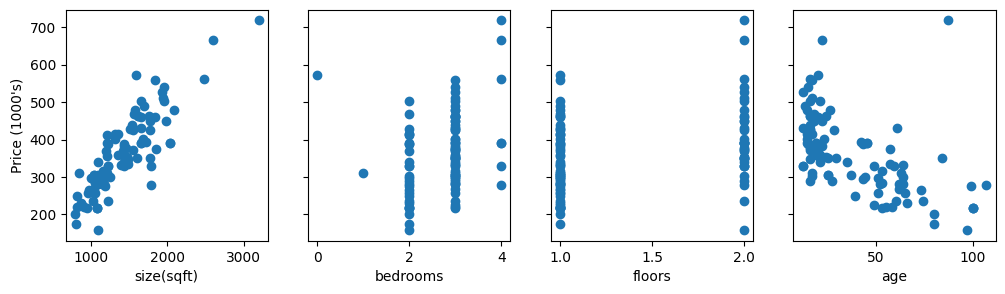

In [18]:
fig,ax=plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train)
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price (1000's)")
plt.show()

In [19]:
w, b, hist = gradient_descent(X_train, y_train,w_init,b_init,compute_cost,compute_gradient,1e-7,10000)
print(f"w and b found by gradient descent {w},{b}")

Iteration    0: Cost 44231.27
Iteration 1000: Cost  1539.19
Iteration 2000: Cost  1504.77
Iteration 3000: Cost  1476.09
Iteration 4000: Cost  1452.20
Iteration 5000: Cost  1432.30
Iteration 6000: Cost  1415.72
Iteration 7000: Cost  1401.91
Iteration 8000: Cost  1390.40
Iteration 9000: Cost  1380.81
w and b found by gradient descent [ 0.26327513 -0.00391898 -0.007732   -0.43467914],0.005704266605712166


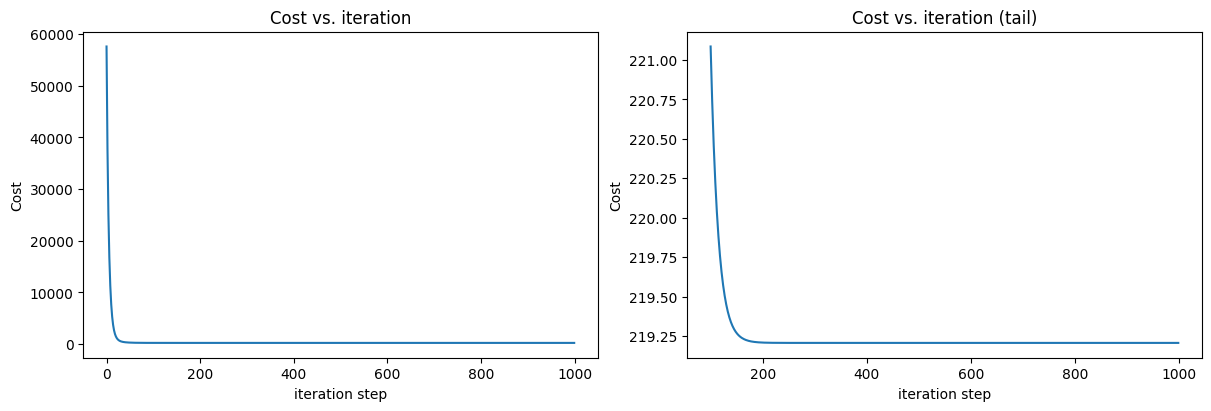

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(hist)
ax2.plot(100 + np.arange(len(hist[100:])), hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()

In [20]:
def zscore_normalize_features(X):
    mu = np.mean(X,axis=0)
    sigma = np.std(X,axis=0)
    X_normalized = (X-mu)/sigma
    return X_normalized,mu,sigma
    

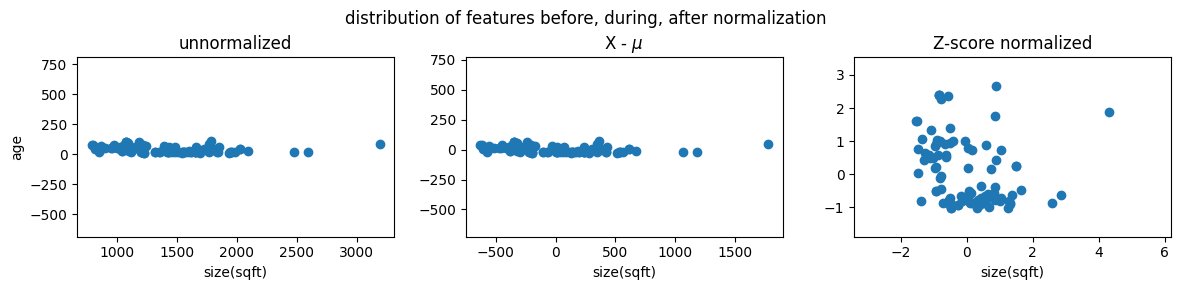

In [21]:
mu     = np.mean(X_train,axis=0)   
sigma  = np.std(X_train,axis=0) 
X_mean = (X_train - mu)
X_norm = (X_train - mu)/sigma      

fig,ax=plt.subplots(1, 3, figsize=(12, 3))
ax[0].scatter(X_train[:,0], X_train[:,3])
ax[0].set_xlabel(X_features[0]); ax[0].set_ylabel(X_features[3]);
ax[0].set_title("unnormalized")
ax[0].axis('equal')

ax[1].scatter(X_mean[:,0], X_mean[:,3])
ax[1].set_xlabel(X_features[0]); ax[0].set_ylabel(X_features[3]);
ax[1].set_title(r"X - $\mu$")
ax[1].axis('equal')

ax[2].scatter(X_norm[:,0], X_norm[:,3])
ax[2].set_xlabel(X_features[0]); ax[0].set_ylabel(X_features[3]);
ax[2].set_title(r"Z-score normalized")
ax[2].axis('equal')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle("distribution of features before, during, after normalization")
plt.show()

In [ ]:
X_norm, X_mu, X_sigma = zscore_normalize_features(X_train)
print(f"X_mu = {X_mu}, \nX_sigma = {X_sigma}")
print(f"Peak to Peak range by column in Raw        X:{np.ptp(X_train,axis=0)}")   
print(f"Peak to Peak range by column in Normalized X:{np.ptp(X_norm,axis=0)}")

Peak to Peak range by column in Raw        X:[2.406e+03 4.000e+00 1.000e+00 9.500e+01]
Peak to Peak range by column in Normalized X:[5.8452591  6.13529646 2.05626214 3.68533012]


In [42]:
w_norm, b_norm, hist = gradient_descent(X_norm, y_train,w_init,b_init,compute_cost,compute_gradient,1.0e-1,200)

Iteration    0: Cost 57617.03
Iteration   20: Cost  1462.59
Iteration   40: Cost   343.31
Iteration   60: Cost   248.04
Iteration   80: Cost   226.54
Iteration  100: Cost   221.09
Iteration  120: Cost   219.69
Iteration  140: Cost   219.33
Iteration  160: Cost   219.24
Iteration  180: Cost   219.21


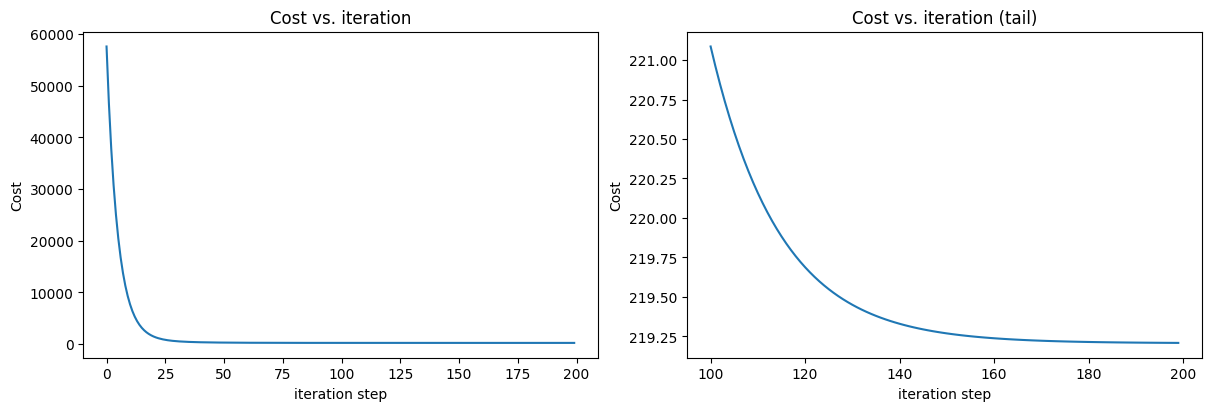

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(hist)
ax2.plot(100 + np.arange(len(hist[100:])), hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()

In [44]:
x_house = np.array([1200, 3, 1, 40])
x_house_norm = (x_house - X_mu) / X_sigma
print(x_house_norm)
print(f"The predicted price {predict(x_house_norm,w_norm,b_norm)}")

[-0.53052829  0.43380884 -0.78927234  0.06269567]
The predicted price 318.736000055377
